# 量子电池效率预测：基于 LSTM 的结构化水库非马尔可夫动力学

本 Notebook 演示完整流程。

> ⚠ 用 12 条曲线做快速演示（~2 分钟）。完整实验请运行 `experiments/` 下的脚本。

## 环境与导入

In [ ]:
import sys, os; sys.path.insert(0, '..')
import numpy as np
import matplotlib.pyplot as plt
import torch, torch.nn as nn
import qutip as qt

from src.physics.hamiltonian import build_dicke_hamiltonian, coupling_operators, build_system_observables
from src.physics.spectral_density import LorentzianSpectralDensity
from src.physics.dynamics import run_heom_simulation, density_matrix_to_features, compute_energy, stored_energy, compute_ergotropy
from src.data.dataset import QuantumBatteryDataset, create_dataloaders
from src.model.lstm import build_model
from src.model.loss import PhysicsInformedLoss, reconstruct_density_matrix
from src.visualization.plot import plot_energy_evolution, plot_training_history, plot_forget_gate_analysis

%matplotlib inline

# ═══════════════════════════════════════════════════════════════
# 可调参数：修改 NUM_TLS 即可切换原子数
# ═══════════════════════════════════════════════════════════════
NUM_TLS = 1               # 二能级系统数量
OMEGA_0 = 1.0             # 裸跃迁频率
DRIVE_AMP = 1.0           # 驱动场振幅
CENTER_FREQ = 1.0         # 水库中心频率

# 自动推导维度
D = 2 ** NUM_TLS                             # Hilbert 空间维度
FEAT_DIM = 2 * D * D                         # 特征维度 = 2*d²（实部+虚部）
E_GROUND = -NUM_TLS * OMEGA_0 / 2.0          # 基态能量

print(f'N={NUM_TLS} TLS | d={D} | feat_dim={FEAT_DIM} | E_ground={E_GROUND:.2f}')
print(f'QuTiP {qt.__version__}  |  PyTorch {torch.__version__}')

---
## 1. 单次 HEOM 模拟

N={NUM_TLS} TLS + 洛伦兹水库。基态能量 $E_{{\text{{ground}}}} = -N\omega_0/2$。
修改顶部 `NUM_TLS` 变量即可切换原子数。

In [ ]:
H_S = build_dicke_hamiltonian(num_tls=NUM_TLS, omega_0=OMEGA_0, drive_amplitude=DRIVE_AMP, t=0)
ops = coupling_operators(num_tls=NUM_TLS, mode='collective')
sd = LorentzianSpectralDensity(coupling_strength=0.1, spectral_width=0.2, center_frequency=CENTER_FREQ)
result = run_heom_simulation(H_S, ops, sd, max_depth=4)
print(f'HEOM: {len(result["times"])} 步,  tau_m={sd.memory_time():.1f},  Omega/gamma={sd.non_markovianity_measure():.2f}')

In [ ]:
H_S_bare = build_system_observables(NUM_TLS, omega_0=OMEGA_0)['H_S']
bare   = np.array([compute_energy(s, H_S_bare) for s in result['states']])
stored = np.array([stored_energy(s, H_S_bare) for s in result['states']])
erg    = np.array([compute_ergotropy(s, H_S_bare) for s in result['states']])

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
ax1.plot(result['times'], bare, 'b-', lw=2)
ax1.axhline(E_GROUND, color='gray', ls=':', alpha=0.5)
ax1.axhline(-E_GROUND, color='gray', ls=':', alpha=0.5)
ax1.set_title('Bare energy Tr[rho*H] (with negative values)'); ax1.set_xlabel('t'); ax1.grid(True, alpha=0.3)
ax2.plot(result['times'], stored, 'b-', lw=2, label='Stored energy')
ax2.plot(result['times'], erg, 'r--', lw=2, label='Ergotropy')
ax2.set_title('Stored energy vs Ergotropy (ground=0)'); ax2.set_xlabel('t'); ax2.legend(); ax2.grid(True, alpha=0.3)
plt.tight_layout(); plt.show()

---
## 2. 批量生成训练数据

$(\Omega, \gamma)$ 网格扫描。12 条曲线用于 Notebook 演示。

In [ ]:
from src.data.generate import generate_dataset, load_config
config = load_config('../config.yaml')
# 传播当前原子数设置
config['physics']['num_tls'] = NUM_TLS
config['physics']['omega_0'] = OMEGA_0
config['physics']['drive_amplitude'] = DRIVE_AMP
config['physics']['center_frequency'] = CENTER_FREQ

# ── 随 N 自适应缩放 ──
# HEOM 深度：N 越大需要越深才能收敛
config['heom']['max_depth'] = {1: 5, 2: 6, 3: 7, 4: 8}.get(NUM_TLS, 8)
# 总时间：更大的 Hilbert 空间需要更多时间演化
config['heom']['total_time'] = {1: 20.0, 2: 25.0, 3: 30.0}.get(NUM_TLS, 30.0)
config['heom']['time_step'] = 0.1
# 参数网格：高维需要更多轨迹，且需避免大 gamma（HEOM 易发散）
if NUM_TLS <= 1:
    config['data']['param_grid'] = {'coupling_strength': [0.1, 0.2, 0.3, 0.4], 'spectral_width': [0.15, 0.5, 1.5]}
elif NUM_TLS == 2:
    config['data']['param_grid'] = {'coupling_strength': [0.05, 0.1, 0.2, 0.3, 0.4], 'spectral_width': [0.1, 0.2, 0.5, 1.0]}
else:  # N >= 3: 限制 gamma <= 0.3，增加 Omega 密度
    config['data']['param_grid'] = {'coupling_strength': [0.05, 0.1, 0.15, 0.2, 0.25, 0.3, 0.4],
                                     'spectral_width': [0.05, 0.1, 0.15, 0.2, 0.3]}

config['data']['output_dir'] = './data/demo_run'
metadata = generate_dataset(config, config['data']['output_dir'])
print(f'Saved {len(metadata)} trajectories (unphysical ones auto-filtered)')
print(f'HEOM max_depth={config["heom"]["max_depth"]}, total_time={config["heom"]["total_time"]}')

In [5]:
train_loader, val_loader, feat_dim = create_dataloaders('./data/demo_run', window_size=20, batch_size=64, train_split=0.8, seed=42)
print(f'训练批: {len(train_loader)}, 验证批: {len(val_loader)}, 特征维度: {feat_dim}')

训练批: 17, 验证批: 6, 特征维度: 8


---
## 3. 训练 LSTM（特征标准化 + 梯度裁剪 + 物理约束）

- **特征标准化**：训练集上计算 μ/σ，训练和验证统一使用
- **物理约束**：反归一化后计算 Trace=1、Hermiticity、Positivity
- **梯度裁剪**：防止梯度爆炸
- **ReduceLROnPlateau**：验证停滞时自动降学习率

In [ ]:
# 获取归一化统计量（训练集上计算）
train_loader, val_loader, feat_dim = create_dataloaders('./data/demo_run', window_size=20, batch_size=64, train_split=0.8, seed=42)
feat_mean = torch.tensor(train_loader.dataset.feature_mean, dtype=torch.float32)
feat_std  = torch.tensor(train_loader.dataset.feature_std, dtype=torch.float32)

# ── 自适应模型容量：hidden 随 N 缩放，避免信息瓶颈 ──
# N=1 (feat=8):   [64, 32], dense=16
# N=2 (feat=32):  [128, 64], dense=32
# N=3 (feat=128): [128, 64], dense=32
# N=4 (feat=512): [256, 128], dense=64
_h1 = max(64, min(256, FEAT_DIM))
_h2 = max(32, _h1 // 2)
LSTM_LAYERS = [_h1, _h2]
DENSE_UNITS = max(16, _h2 // 2)

model = build_model(input_dim=FEAT_DIM, output_dim=FEAT_DIM, lstm_layers=LSTM_LAYERS, dense_units=DENSE_UNITS, dropout=0.2)
criterion = PhysicsInformedLoss(lambda_trace=1.0, lambda_herm=1.0, lambda_pos=0.1, d=D)
optimizer = torch.optim.Adam(model.parameters(), lr=0.001, weight_decay=1e-5)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=20)
print(f'Params: {sum(p.numel() for p in model.parameters()):,}  |  Arch: {FEAT_DIM} -> LSTM{LSTM_LAYERS} -> Dense[{DENSE_UNITS}] -> {FEAT_DIM}')

In [7]:
history = []; best_val = float('inf'); no_improve = 0; best_epoch = 0
for epoch in range(1, 201):
    model.train()
    train_loss = 0
    for X, y in train_loader:
        optimizer.zero_grad()
        pred = model(X)
        # 反归一化后计算物理约束
        pred_raw = pred * feat_std + feat_mean
        y_raw    = y * feat_std + feat_mean
        loss = criterion(pred_raw, y_raw)
        loss.backward()
        nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()
        train_loss += loss.item()
    train_loss /= len(train_loader)

    model.eval()
    val_loss = 0
    with torch.no_grad():
        for X, y in val_loader:
            pred = model(X)
            pred_raw = pred * feat_std + feat_mean
            y_raw    = y * feat_std + feat_mean
            val_loss += criterion(pred_raw, y_raw).item()
    val_loss /= len(val_loader)
    scheduler.step(val_loss)

    comps = criterion.get_component_losses()
    history.append({'epoch': epoch, 'train_loss': train_loss, 'val_loss': val_loss,
                    **{f'train_{k}': v for k, v in comps.items()}})

    if val_loss < best_val - 1e-7:
        os.makedirs('./models', exist_ok=True)
        best_val = val_loss; best_epoch = epoch; no_improve = 0
        torch.save(model.state_dict(), './models/demo_best.pt')
    else:
        no_improve += 1

    if epoch % 30 == 0 or epoch == 1:
        print(f'E {epoch:3d} | train={train_loss:.6f} | val={val_loss:.6f} | best@{best_epoch}')
    if no_improve >= 40: break

print(f'\n✅ best epoch {best_epoch}, val_loss={best_val:.6f}')


E   1 | train=0.143758 | val=0.053986 | best@1
E  30 | train=0.014103 | val=0.006334 | best@30
E  60 | train=0.006047 | val=0.001613 | best@56
E  90 | train=0.005549 | val=0.001492 | best@77
E 120 | train=0.005421 | val=0.001384 | best@97
E 150 | train=0.005464 | val=0.001162 | best@128
E 180 | train=0.004928 | val=0.001224 | best@172

✅ best epoch 188, val_loss=0.001040


Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], 

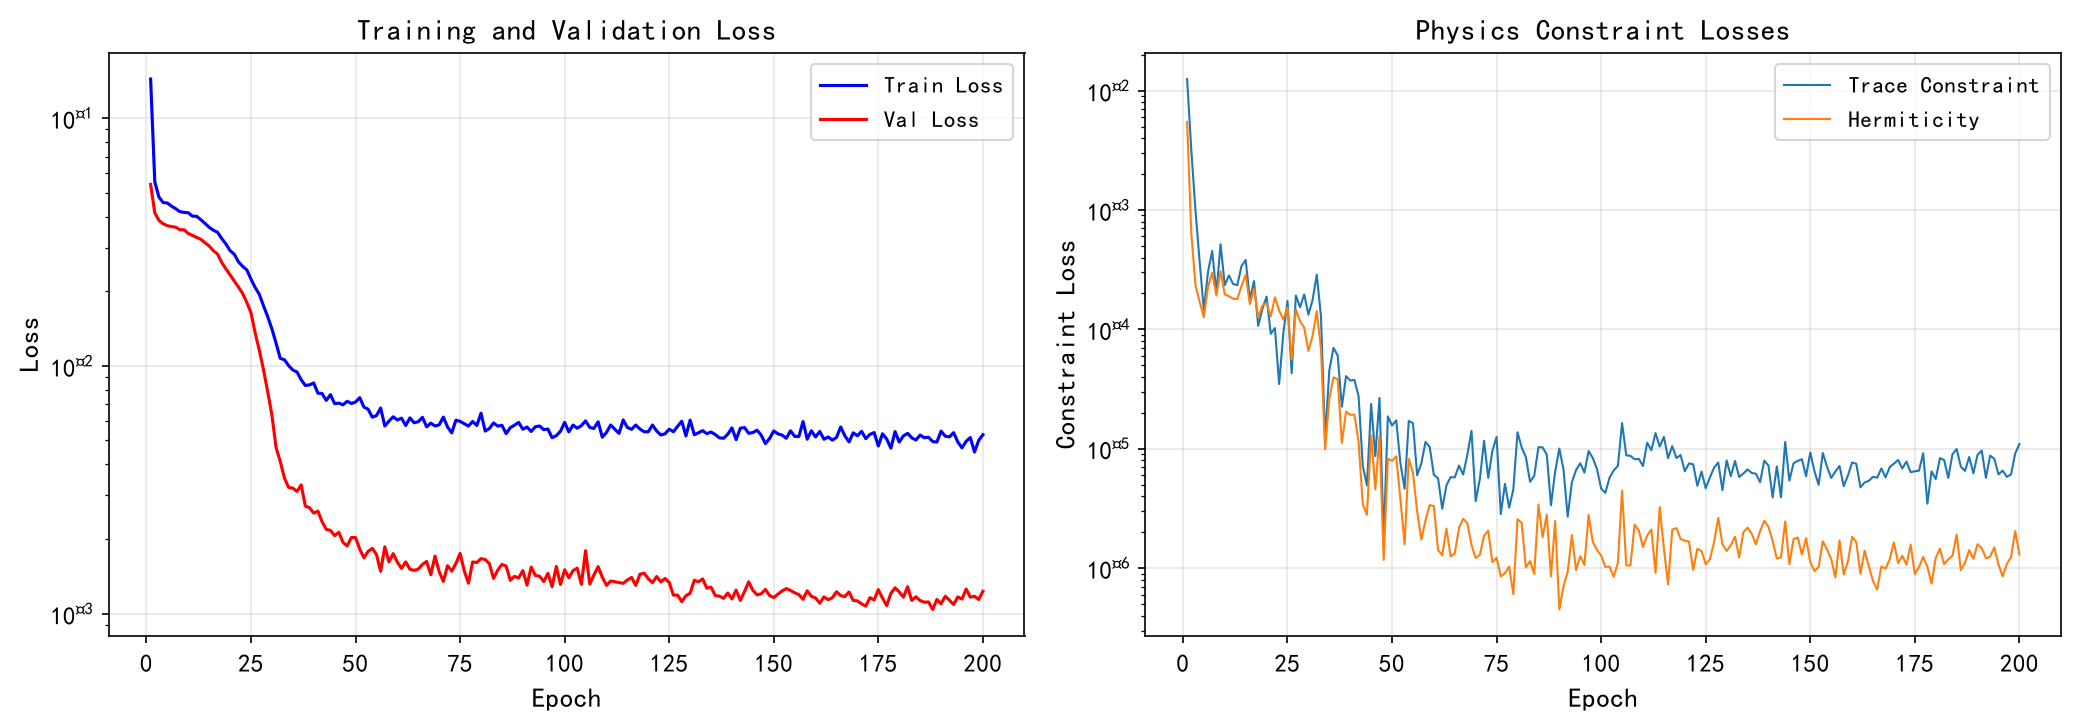

In [8]:
plot_training_history(history); plt.show()

---
## 4. 评估预测效果

加载最佳模型，对验证轨迹做自回归预测。

In [ ]:
device = torch.device('cpu')
model_pt = build_model(input_dim=FEAT_DIM, output_dim=FEAT_DIM, lstm_layers=LSTM_LAYERS, dense_units=DENSE_UNITS)
model_pt.load_state_dict(torch.load('./models/demo_best.pt', map_location=device, weights_only=True))
model_pt.eval()

# Load val dataset with same normalization as training
val_ds = QuantumBatteryDataset('./data/demo_run', window_size=20, train=False, train_split=0.8, seed=42,
                                feature_mean=feat_mean.numpy(), feature_std=feat_std.numpy())

# Build H_S dynamically from system observables
H_S_bare = build_system_observables(NUM_TLS, omega_0=OMEGA_0)['H_S']
H_S_diag = H_S_bare.full()  # dense matrix in computational basis

fm = feat_mean.numpy()
fs = feat_std.numpy()

for idx in range(min(4, len(val_ds.traj_indices))):
    traj = val_ds.get_full_trajectory(val_ds.traj_indices[idx])
    feats_raw, times = traj['features'], traj['times']
    true_bare = traj['energies']                # bare energy from data
    true_stored = true_bare - E_GROUND          # stored = bare - E_ground
    ws = val_ds.window_size

    # Normalize input window
    feats_norm = (feats_raw - fm) / (fs + 1e-8)
    window = torch.tensor(feats_norm[:ws], dtype=torch.float32).unsqueeze(0)
    
    pred_stored = []
    with torch.no_grad():
        for step in range(len(feats_raw) - ws):
            p_norm = model_pt(window).cpu().numpy()[0]
            # Denormalize
            p_raw = p_norm * fs + fm
            half = FEAT_DIM // 2
            rho = p_raw[:half].reshape(D, D) + 1j * p_raw[half:].reshape(D, D)
            # stored_energy = Tr[rho * H_S] - E_ground
            e_bare = np.real(np.trace(rho @ H_S_diag))
            e_stored = e_bare - E_GROUND
            pred_stored.append(e_stored)
            # Teacher forcing: use true next step for window
            nxt = torch.tensor(feats_norm[ws+step], dtype=torch.float32).unsqueeze(0).unsqueeze(0)
            window = torch.cat([window[:,1:,:], nxt], dim=1)
    
    pred_stored = np.array(pred_stored)
    true_range = true_stored[ws:]
    mse = np.mean((pred_stored - true_range)**2)
    params = traj['params']
    print(f'Traj {idx}: Omega={params["coupling_strength"]}, gamma={params["spectral_width"]}, MSE={mse:.6f}')

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
    ax1.plot(times, true_stored, 'b-', lw=2, label='True stored energy')
    ax1.plot(times[ws:], pred_stored, 'r--', lw=2, label='Predicted')
    ax1.axvline(times[ws], color='gray', ls=':', alpha=0.5)
    ax1.set_title(f'Omega={params["coupling_strength"]}, gamma={params["spectral_width"]}')
    ax1.set_ylabel('Stored energy'); ax1.set_xlabel('t'); ax1.legend(); ax1.grid(True, alpha=0.3)
    ax2.plot(times[ws:], np.abs(pred_stored - true_range), 'purple', lw=1.5)
    ax2.fill_between(times[ws:], 0, np.abs(pred_stored - true_range), alpha=0.3, color='purple')
    ax2.set_title(f'Error (MSE={mse:.6f})'); ax2.set_xlabel('t'); ax2.grid(True, alpha=0.3)
    plt.tight_layout(); plt.show()

---
## 5. 遗忘门分析

In [ ]:
fw = model_pt.get_forget_gate_weights().numpy()
print(f'Forget gate weights: {fw.shape}, mean={fw.mean():.4f}')

# Generate feature labels dynamically for any N
half = FEAT_DIM // 2
labels = []
for i in range(D):
    for j in range(D):
        labels.append(f'Re(rho_{i}{j})')
for i in range(D):
    for j in range(D):
        labels.append(f'Im(rho_{i}{j})')
plot_forget_gate_analysis(fw, labels); plt.show()

---
## 6. 完整实验

| 实验 | 命令 |
|------|------|
| 非马尔可夫增强 | `python experiments/experiment_a_feedback.py` |
| 存储寿命预测 | `python experiments/experiment_b_shelflife.py` |
| 跨参数外推 | `python experiments/experiment_c_extrapolation.py` |